In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [2]:
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

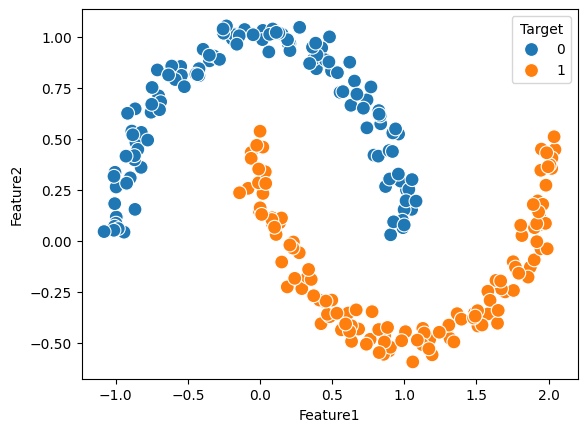

In [3]:

import seaborn as sns
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="Target", s=100)
plt.show()

In [4]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/opt/anaconda3/envs/ai_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-03 06:57:40.768925: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-03 06:57:40.768953: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-03 06:57:40.768966: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-03 06:57:40.768985: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 06:57:40.769001: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created 

In [5]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [6]:
model.get_weights()[0]

array([[ 0.4501595 , -0.51093423, -0.3428771 , -0.405832  , -0.58044875,
         0.6292309 ,  0.50056547,  0.3889379 ,  0.05792511, -0.28078634],
       [ 0.15746415, -0.42634672, -0.37223607,  0.15107638,  0.41506642,
         0.24820852, -0.0060764 , -0.22502133, -0.3655182 ,  0.21349013]],
      dtype=float32)

In [7]:
old_weights = model.get_weights()[0]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [9]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100


2026-03-03 06:57:41.306747: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5100 - loss: 0.6946
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5100 - loss: 0.6922
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6915
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6906
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6898
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6892
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6887
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6883
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6877
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6870
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.6864
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6860
E

In [10]:
new_weights = model.get_weights()[0]

In [11]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [12]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [13]:
gradient

array([[ -464.90262,   471.76083,   490.03955,   438.37347,   389.25397,
          193.01143,  -424.79233,  -421.00876,  -517.50543,  -467.60706],
       [ 1110.6481 , -1066.0496 , -1016.41815,  -983.83765, -1074.7938 ,
         -852.71173,  1016.22266,   978.8583 ,   975.22375,   851.44336]],
      dtype=float32)

In [14]:
percent_change

array([[  103.27509 ,    92.33299 ,   142.9199  ,   108.01846 ,
           67.06087 ,    30.674183,    84.862495,   108.24576 ,
          893.4044  ,   166.53484 ],
       [  705.33405 ,   250.04288 ,   273.05743 ,   651.21875 ,
          258.94504 ,   343.54654 , 16724.104   ,   435.0069  ,
          266.8058  ,   398.82098 ]], dtype=float32)

In [15]:
old_weights

array([[ 0.4501595 , -0.51093423, -0.3428771 , -0.405832  , -0.58044875,
         0.6292309 ,  0.50056547,  0.3889379 ,  0.05792511, -0.28078634],
       [ 0.15746415, -0.42634672, -0.37223607,  0.15107638,  0.41506642,
         0.24820852, -0.0060764 , -0.22502133, -0.3655182 ,  0.21349013]],
      dtype=float32)

In [16]:
new_weights

array([[ 0.9150621 , -0.9826951 , -0.8329167 , -0.8442055 , -0.9697027 ,
         0.43621948,  0.9253578 ,  0.80994666,  0.5754306 ,  0.18682075],
       [-0.95318407,  0.6397028 ,  0.6441822 ,  1.134914  ,  1.4898602 ,
         1.1009203 , -1.022299  , -1.2038797 , -1.340742  , -0.6379533 ]],
      dtype=float32)

In [17]:
nw= pd.DataFrame(new_weights)

In [18]:
nw

,0,1,2,3,4,5,6,7,8,9
0,0.915062,-0.982695,-0.832917,-0.844205,-0.969703,0.436219,0.925358,0.809947,0.575431,0.186821
1,-0.953184,0.639703,0.644182,1.134914,1.489860,1.100920,-1.022299,-1.203880,-1.340742,-0.637953


In [19]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/opt/anaconda3/envs/ai_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
old_weights = model.get_weights()[0]

In [22]:
model.fit(X_train, y_train, epochs = 51)

Epoch 1/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6600 - loss: 0.6792
Epoch 2/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6500 - loss: 0.6529
Epoch 3/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6600 - loss: 0.6280
Epoch 4/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7100 - loss: 0.5983
Epoch 5/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7050 - loss: 0.5665
Epoch 6/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7450 - loss: 0.5270
Epoch 7/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7600 - loss: 0.4713
Epoch 8/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7850 - loss: 0.4076
Epoch 9/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8050 - loss: 0.3637
Epoch 10/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8100 - loss: 0.3402
Epoch 11/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8250 - loss: 0.3228
Epoch 12/51
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8450 - loss: 0.3129
E

In [23]:
new_weights = model.get_weights()[0]

In [24]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [25]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [26]:
gradient

array([[ 264.72537  ,   95.57879  ,   -9.800329 ,   27.107178 ,
         -85.98977  , -170.89163  ,   72.14337  ,  216.46484  ,
         -79.35854  ,   18.535137 ],
       [-153.93071  ,   48.328487 , -105.31535  ,  101.189575 ,
        -292.2666   , -227.69576  ,  287.86957  ,    1.1469424,
        -298.01285  ,   10.426328 ]], dtype=float32)

In [27]:
percent_change

array([[ 37.552315  ,  33.404617  ,   9.258302  ,   6.726977  ,
         16.620026  ,  41.02546   ,  18.160704  ,  61.55725   ,
         38.55904   ,   2.9846418 ],
       [ 26.790165  ,  15.132266  , 153.40057   , 102.46478   ,
         65.74396   ,  39.22836   ,  57.148754  ,   0.23468727,
         88.21933   ,  65.92948   ]], dtype=float32)

In [28]:
old_weights

array([[-0.70495087,  0.28612447, -0.10585451,  0.40296227,  0.5173865 ,
         0.41655022,  0.39724988, -0.351648  ,  0.20581049,  0.62101716],
       [-0.57457924,  0.3193738 ,  0.06865382, -0.09875548,  0.44455284,
         0.58043665, -0.50371975,  0.48871094,  0.33780903,  0.01581436]],
      dtype=float32)

In [29]:
new_weights

array([[-0.96967626,  0.19054568, -0.09605418,  0.3758551 ,  0.60337627,
         0.58744186,  0.3251065 , -0.56811285,  0.28516904,  0.602482  ],
       [-0.42064852,  0.2710453 ,  0.17396918, -0.19994506,  0.73681945,
         0.8081324 , -0.7915893 ,  0.487564  ,  0.6358219 ,  0.00538804]],
      dtype=float32)